# DATASET1 

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
df=pd.read_csv('dataset/watson_healthcare_modified.csv')
df=df.drop(columns=["EmployeeID"])
df=df.drop(columns=["Over18","EmployeeCount","StandardHours"])
len(df.columns)

col = df["Attrition"]
df = df.drop("Attrition", axis=1)
df["Attrition"] = col

In [38]:

CategoricalCols=np.zeros(len(df.columns))
NumericCols=np.zeros(len(df.columns))

CategoricalColsIndex=[] # index from 0
NumericColsIndex=[]
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
    if dtype=="object":
        CategoricalCols[i]=1
        CategoricalColsIndex.append(i)
        df[col] = df[col].astype('category')
    else:
        NumericCols[i]=1
        NumericColsIndex.append(i)

df["Attrition"] = df["Attrition"].map({"No": 0, "Yes": 1})
cols_to_drop = [col for col in df.select_dtypes(include=["category"]).columns if col != "Attrition"]
df = df.drop(columns=cols_to_drop)


In [39]:
numcols=np.ones(len(df.columns)-1)
catcol=np.zeros(len(df.columns)-1)

In [42]:
len(numcols)

23

In [5]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

In [6]:
from acm import Binclassification
Binaryclassobj=Binclassification(X,y,numcols,catcol)

In [7]:
Binaryclassobj.simulate_ntimes()

Before Sampling train_X: (1173, 23)
Before Sampling train_y: (1173,) 

SAMPLING WITH SMOTE
After Sampling train_X: (2068, 23)
After Sampling train_y: (2068,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (1173, 23)
Before Sampling train_y: (1173,) 

SAMPLING WITH Smote Tomek
After Sampling train_X: (2068, 23)
After Sampling train_y: (2068,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (1173, 23)
Before Sampling train_y: (1173,) 

SAMPLING WITH Smote ENN
After Sampling train_X: (1655, 23)
After Sampling train_y: (1655,) 

inside the loop 1
Fittin

In [9]:
results_n=Binaryclassobj.simulation_result_n
results_n.keys()

dict_keys(['sampling 1', 'sampling 2', 'sampling 3', 'sampling 4', 'sampling 5', 'sampling 6', 'sampling 7'])

In [10]:
import pickle

with open("Result_dataset_medical.pkl", "wb") as f:
    pickle.dump(results_n, f)

In [12]:
with open("Result_dataset_medical.pkl", "rb") as f:
    results_n = pickle.load(f)

In [13]:
results_n

{'sampling 1': {'LogisticRegression': {'best_estimator': LogisticRegression(C=np.float64(0.03359818286283781), max_iter=5000,
                      solver='liblinear'),
   'best_score': np.float64(0.80658505698607),
   'best_params': {'C': np.float64(0.03359818286283781),
    'penalty': 'l2',
    'solver': 'liblinear'},
   'test_result': {'Accuracy': 0.7773359840954275,
    'Sensitivity': 0.7333333333333333,
    'Specificity': np.float64(0.7832957110609481),
    'Precision': 0.3142857142857143,
    'F1-score': 0.44,
    'AUC': 0.8366817155756208}},
  'RandomForest': {'best_estimator': RandomForestClassifier(max_depth=20, n_estimators=300),
   'best_score': np.float64(0.9560058158622953),
   'best_params': {'max_depth': 20,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 300},
   'test_result': {'Accuracy': 0.9065606361829026,
    'Sensitivity': 0.4166666666666667,
    'Specificity': np.float64(0.9729119638826185),
    'Precision': 0.6756756756756757,
    'F1-

# dataset2 

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [44]:
df=pd.read_csv("dataset/dataset2_indian.csv")
df=df.drop(columns=["EmployeeID","FullName","DateOfJoining"])
col = df["LeftCompany"]
df = df.drop("LeftCompany", axis=1)
df["LeftCompany"] = col



In [45]:
df.head()

,Age,Gender,Department,Designation,EducationQualification,MonthlySalary,YearsWithCompany,YearsInRole,AppraisalRating,TrainingHours,DoesOvertime,JobSatisfaction,WorkLifeBalance,MaritalStatus,PreviousCompanies,DistanceFromHome,LeavesTaken,City,LeftCompany
0,48,Other,HR,Accounts Officer,B.Tech,111813,5,0,3,37,Yes,4,3,Single,0,12.2,4,Mumbai,No
1,26,Female,IT,Accounts Officer,B.Tech,87425,5,2,3,39,No,2,2,Divorced,0,36.7,29,Kolkata,No
2,40,Male,IT,Software Engineer,Diploma,86461,4,4,2,32,No,2,3,Married,1,45.4,0,Bengaluru,Yes
3,54,Other,HR,Accounts Officer,Diploma,23720,2,2,1,21,Yes,4,4,Married,0,29.9,27,Kolkata,No
4,51,Other,Admin,Sales Associate,B.Tech,39041,7,1,1,30,No,2,2,Single,0,26.8,6,Delhi,Yes


In [46]:
df.dtypes

Age                         int64
Gender                     object
Department                 object
Designation                object
EducationQualification     object
MonthlySalary               int64
YearsWithCompany            int64
YearsInRole                 int64
AppraisalRating             int64
TrainingHours               int64
DoesOvertime               object
JobSatisfaction             int64
WorkLifeBalance             int64
MaritalStatus              object
PreviousCompanies           int64
DistanceFromHome          float64
LeavesTaken                 int64
City                       object
LeftCompany                object
dtype: object

In [47]:

CategoricalCols=np.zeros(len(df.columns))
NumericCols=np.zeros(len(df.columns))

CategoricalColsIndex=[] # index from 0
NumericColsIndex=[]
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
    if dtype=="object":
        CategoricalCols[i]=1
        CategoricalColsIndex.append(i)
        df[col] = df[col].astype('category')
    else:
        NumericCols[i]=1
        NumericColsIndex.append(i)

df["LeftCompany"] = df["LeftCompany"].map({"No": 0, "Yes": 1})
cols_to_drop = [col for col in df.select_dtypes(include=["category"]).columns if col != "LeftCompany"]
df = df.drop(columns=cols_to_drop)


In [20]:
# df.dtypes

In [48]:
numcols=np.ones(len(df.columns)-1)
catcol=np.zeros(len(df.columns)-1)
len(numcols)

11

In [22]:
X = df.drop(columns=['LeftCompany'])
y = df['LeftCompany']

In [23]:
from acm import Binclassification
Binaryclassobj=Binclassification(X,y,numcols,catcol)

In [24]:
Binaryclassobj.simulate_ntimes()

Before Sampling train_X: (3500, 11)
Before Sampling train_y: (3500,) 

SAMPLING WITH SMOTE
After Sampling train_X: (4402, 11)
After Sampling train_y: (4402,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (3500, 11)
Before Sampling train_y: (3500,) 

SAMPLING WITH Smote Tomek
After Sampling train_X: (4120, 11)
After Sampling train_y: (4120,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (3500, 11)
Before Sampling train_y: (3500,) 

SAMPLING WITH Smote ENN
After Sampling train_X: (1940, 11)
After Sampling train_y: (1940,) 

inside the loop 1
Fittin

In [25]:
results_n=Binaryclassobj.simulation_result_n
results_n.keys()

dict_keys(['sampling 1', 'sampling 2', 'sampling 3', 'sampling 4', 'sampling 5', 'sampling 6', 'sampling 7'])

In [26]:
import pickle

with open("Result_dataset_indian.pkl", "wb") as f:
    pickle.dump(results_n, f)

In [27]:
with open("Result_dataset_indian.pkl", "rb") as f:
    results_n = pickle.load(f)

In [28]:
results_n

{'sampling 1': {'LogisticRegression': {'best_estimator': LogisticRegression(C=np.float64(0.615848211066026), max_iter=5000, penalty='l1',
                      solver='liblinear'),
   'best_score': np.float64(0.6440254586683158),
   'best_params': {'C': np.float64(0.615848211066026),
    'penalty': 'l1',
    'solver': 'liblinear'},
   'test_result': {'Accuracy': 0.6386666666666667,
    'Sensitivity': 0.6294964028776978,
    'Specificity': np.float64(0.6440677966101694),
    'Precision': 0.5102040816326531,
    'F1-score': 0.5636070853462157,
    'AUC': 0.6925489269601268}},
  'RandomForest': {'best_estimator': RandomForestClassifier(n_estimators=200),
   'best_score': np.float64(0.7980823541537827),
   'best_params': {'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 200},
   'test_result': {'Accuracy': 0.7273333333333334,
    'Sensitivity': 0.49640287769784175,
    'Specificity': np.float64(0.8633474576271186),
    'Precision': 0.68148148148

# Dataset 3

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [50]:
df=pd.read_csv("dataset/dataset3_manufacture.csv")


In [51]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [52]:
col = df["left"]
df = df.drop("left", axis=1)
df["left"] = col


In [53]:
# df["Work_accident"]=df["Work_accident"].astype('category')
# df["promotion_last_5years"]=df["promotion_last_5years"].astype('category')
df["left"]=df["left"].astype('category')
df["salary"]=df["salary"].astype('category')
df["Department"]=df["Department"].astype('category')

In [54]:
df.dtypes

satisfaction_level        float64
last_evaluation           float64
number_project              int64
average_montly_hours        int64
time_spend_company          int64
Work_accident               int64
promotion_last_5years       int64
Department               category
salary                   category
left                     category
dtype: object

In [55]:
cols_to_drop = [col for col in df.select_dtypes(include=["category"]).columns if col != "left"]
df = df.drop(columns=cols_to_drop)

In [56]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,left
0,0.38,0.53,2,157,3,0,0,1
1,0.80,0.86,5,262,6,0,0,1
2,0.11,0.88,7,272,4,0,0,1
3,0.72,0.87,5,223,5,0,0,1
4,0.37,0.52,2,159,3,0,0,1


In [57]:
numcols=np.ones(len(df.columns)-1)
catcol=np.zeros(len(df.columns)-1)

In [58]:
numcols

array([1., 1., 1., 1., 1., 1., 1.])

In [29]:
X = df.drop(columns=['left'])
y = df['left']


In [30]:
from acm import Binclassification
Binaryclassobj=Binclassification(X,y,numcols,catcol)

In [31]:
Binaryclassobj.simulate_ntimes()

Before Sampling train_X: (10499, 7)
Before Sampling train_y: (10499,) 

SAMPLING WITH SMOTE
After Sampling train_X: (15998, 7)
After Sampling train_y: (15998,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (10499, 7)
Before Sampling train_y: (10499,) 

SAMPLING WITH Smote Tomek
After Sampling train_X: (15944, 7)
After Sampling train_y: (15944,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (10499, 7)
Before Sampling train_y: (10499,) 

SAMPLING WITH Smote ENN
After Sampling train_X: (15270, 7)
After Sampling train_y: (15270,) 

inside the loop 1


In [32]:
results_n=Binaryclassobj.simulation_result_n
results_n.keys()

dict_keys(['sampling 1', 'sampling 2', 'sampling 3', 'sampling 4', 'sampling 5', 'sampling 6', 'sampling 7'])

In [33]:
import pickle

with open("Result_dataset_manufacture.pkl", "wb") as f:
    pickle.dump(results_n, f)

In [34]:
with open("Result_dataset_manufacture.pkl", "rb") as f:
    results_n = pickle.load(f)

In [35]:
results_n

{'sampling 1': {'LogisticRegression': {'best_estimator': LogisticRegression(C=np.float64(0.615848211066026), max_iter=5000,
                      solver='liblinear'),
   'best_score': np.float64(0.7632221310193871),
   'best_params': {'C': np.float64(0.615848211066026),
    'penalty': 'l2',
    'solver': 'liblinear'},
   'test_result': {'Accuracy': 0.752,
    'Sensitivity': 0.7684407096171803,
    'Specificity': np.float64(0.7468649752114319),
    'Precision': 0.4866942637492608,
    'F1-score': 0.5959449674149168,
    'AUC': 0.8147170601496163}},
  'RandomForest': {'best_estimator': RandomForestClassifier(max_depth=20, n_estimators=300),
   'best_score': np.float64(0.9890615228267666),
   'best_params': {'max_depth': 20,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 300},
   'test_result': {'Accuracy': 0.9895555555555555,
    'Sensitivity': 0.965452847805789,
    'Specificity': np.float64(0.9970836978710994),
    'Precision': 0.9904214559386973,
    'F1-sc

# Dataset 4

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [60]:
df=pd.read_csv("dataset/dataset4_turnover.csv",encoding="latin1")
col = df["event"]
df = df.drop("event", axis=1)
df["event"] = col

In [61]:
df.dtypes

stag            float64
gender           object
age             float64
industry         object
profession       object
traffic          object
coach            object
head_gender      object
greywage         object
way              object
extraversion    float64
independ        float64
selfcontrol     float64
anxiety         float64
novator         float64
event             int64
dtype: object

In [62]:

CategoricalCols=np.zeros(len(df.columns))
NumericCols=np.zeros(len(df.columns))

CategoricalColsIndex=[] # index from 0
NumericColsIndex=[]
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes)):
    if dtype=="object":
        CategoricalCols[i]=1
        CategoricalColsIndex.append(i)
        df[col] = df[col].astype('category')
    else:
        NumericCols[i]=1
        NumericColsIndex.append(i)

cols_to_drop = [col for col in df.select_dtypes(include=["category"]).columns if col != "event"]
df = df.drop(columns=cols_to_drop)

In [63]:
df.dtypes

stag            float64
age             float64
extraversion    float64
independ        float64
selfcontrol     float64
anxiety         float64
novator         float64
event             int64
dtype: object

In [64]:
df.head()

,stag,age,extraversion,independ,selfcontrol,anxiety,novator,event
0,7.030801,35.0,6.2,4.1,5.7,7.1,8.3,1
1,22.965092,33.0,6.2,4.1,5.7,7.1,8.3,1
2,15.934292,35.0,6.2,6.2,2.6,4.8,8.3,1
3,15.934292,35.0,5.4,7.6,4.9,2.5,6.7,1
4,8.410678,32.0,3.0,4.1,8.0,7.1,3.7,1


In [65]:
numcols=np.ones(len(df.columns)-1)
catcol=np.zeros(len(df.columns)-1)

In [66]:
numcols

array([1., 1., 1., 1., 1., 1., 1.])

In [8]:
X = df.drop(columns=['event'])
y = df['event']


In [9]:
from acm import Binclassification
Binaryclassobj=Binclassification(X,y,numcols,catcol)

In [10]:
# y.value_counts()

In [11]:
from acm import Binclassification
Binaryclassobj=Binclassification(X,y,numcols,catcol)

In [12]:
Binaryclassobj.simulate_ntimes()

Before Sampling train_X: (790, 7)
Before Sampling train_y: (790,) 

SAMPLING WITH SMOTE
After Sampling train_X: (800, 7)
After Sampling train_y: (800,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (790, 7)
Before Sampling train_y: (790,) 

SAMPLING WITH Smote Tomek
After Sampling train_X: (636, 7)
After Sampling train_y: (636,) 

inside the loop 1
Fitting 10 folds for each of 40 candidates, totalling 400 fits
inside the loop 1
Fitting 10 folds for each of 108 candidates, totalling 1080 fits
inside the loop 1
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Before Sampling train_X: (790, 7)
Before Sampling train_y: (790,) 

SAMPLING WITH Smote ENN
After Sampling train_X: (151, 7)
After Sampling train_y: (151,) 

inside the loop 1
Fitting 10 folds for eac

In [13]:
results_n=Binaryclassobj.simulation_result_n
results_n.keys()

dict_keys(['sampling 1', 'sampling 2', 'sampling 3', 'sampling 4', 'sampling 5', 'sampling 6', 'sampling 7'])

In [15]:
import pickle

with open("Result_dataset_4.pkl", "wb") as f:
    pickle.dump(results_n, f)

In [18]:
with open("Result_dataset_4.pkl", "rb") as f:
    results_n = pickle.load(f)

In [19]:
results_n

{'sampling 1': {'LogisticRegression': {'best_estimator': LogisticRegression(C=np.float64(0.004832930238571752), max_iter=5000,
                      solver='liblinear'),
   'best_score': np.float64(0.525),
   'best_params': {'C': np.float64(0.004832930238571752),
    'penalty': 'l2',
    'solver': 'liblinear'},
   'test_result': {'Accuracy': 0.5103244837758112,
    'Sensitivity': 0.5146198830409356,
    'Specificity': np.float64(0.5059523809523809),
    'Precision': 0.5146198830409356,
    'F1-score': 0.5146198830409356,
    'AUC': 0.5252715121136173}},
  'RandomForest': {'best_estimator': RandomForestClassifier(n_estimators=200),
   'best_score': np.float64(0.615),
   'best_params': {'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 200},
   'test_result': {'Accuracy': 0.6047197640117994,
    'Sensitivity': 0.5614035087719298,
    'Specificity': np.float64(0.6488095238095238),
    'Precision': 0.6193548387096774,
    'F1-score': 0.5889570552

# EXTRA/CHART

In [ ]:
import pandas as pd

map = {
    "sampling 1": "SMOTE",
    "sampling 2": "Tomek",
    "sampling 3": "SMOTE-ENN",
    "sampling 4": "BorderlineSMOTE1",
    "sampling 5": "BorderlineSMOTE2",
    "sampling 6": "KMeansSMOTE",
    "sampling 7": "Adasyn"
}

tables = {name: pd.DataFrame(columns=[
    "Dataset","Model","Accuracy","Sensitivity",
    "Specificity","Precision","F1-score","AUC"
]) for name in map.values()}


def append_results(results_dict, dataset_name):
    
    for sampling_key, models in results_dict.items():
        
        sampling_name = map[sampling_key]
        
        for model_name, model_data in models.items():
            
            metrics = model_data["test_result"]
            
            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                "Accuracy": metrics["Accuracy"],
                "Sensitivity": metrics["Sensitivity"],
                "Specificity": metrics["Specificity"],
                "Precision": metrics["Precision"],
                "F1-score": metrics["F1-score"],
                "AUC": metrics["AUC"]
            }
            
            tables[sampling_name] = pd.concat(
                [tables[sampling_name], pd.DataFrame([row])],
                ignore_index=True
            )

In [3]:
import pickle

In [4]:
with open("Result_dataset_medical.pkl", "rb") as f:
    dataset1 = pickle.load(f)
    
with open("Result_dataset_indian.pkl", "rb") as f:
    dataset2 = pickle.load(f)

with open("Result_dataset_manufacture.pkl", "rb") as f:
    dataset3 = pickle.load(f)

with open("Result_dataset_4.pkl", "rb") as f:
    dataset4 = pickle.load(f)

In [ ]:
import pandas as pd

datasets = {
    "D1": dataset1,
    "D2": dataset2,
    "D3": dataset3,
    "D4": dataset4
}

sampling_map = {
    "sampling 1": "SMOTE",
    "sampling 2": "Tomek",
    "sampling 3": "SMOTE_ENN",
    "sampling 4": "Borderline_SMOTE1",
    "sampling 5": "Borderline_SMOTE2",
    "sampling 6": "KMeans_SMOTE",
    "sampling 7": "ADASYN"
}

tables = {name: [] for name in sampling_map.values()}


for dataset_name, dataset_results in datasets.items():

    for sampling_key, models in dataset_results.items():

        sampling_name = sampling_map[sampling_key]

        for model_name, model_data in models.items():

            metrics = model_data["test_result"]

            tables[sampling_name].append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Accuracy": metrics["Accuracy"],
                "Sensitivity": metrics["Sensitivity"],
                "Specificity": metrics["Specificity"],
                "Precision": metrics["Precision"],
                "F1-score": metrics["F1-score"],
                "AUC": metrics["AUC"]
            })


tables_df = {k: pd.DataFrame(v) for k,v in tables.items()}


print(tables_df["SMOTE"])

   Dataset               Model  Accuracy  Sensitivity  Specificity  Precision  \
0       D1  LogisticRegression  0.777336     0.733333     0.783296   0.314286   
1       D1        RandomForest  0.906561     0.416667     0.972912   0.675676   
2       D1            AdaBoost  0.880716     0.466667     0.936795   0.500000   
3       D2  LogisticRegression  0.638667     0.629496     0.644068   0.510204   
4       D2        RandomForest  0.727333     0.496403     0.863347   0.681481   
5       D2            AdaBoost  0.718000     0.544964     0.819915   0.640592   
6       D3  LogisticRegression  0.752000     0.768441     0.746865   0.486694   
7       D3        RandomForest  0.989556     0.965453     0.997084   0.990421   
8       D3            AdaBoost  0.928444     0.940243     0.924759   0.796047   
9       D4  LogisticRegression  0.510324     0.514620     0.505952   0.514620   
10      D4        RandomForest  0.604720     0.561404     0.648810   0.619355   
11      D4            AdaBoo

In [ ]:
# append_results(dataset1, "D1")
# append_results(dataset2,"D2")
# append_results(dataset3,"D3")
# append_results(dataset4,"D4")

C:\Users\ankit\AppData\Local\Temp\ipykernel_23048\2207580460.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tables[sampling_name] = pd.concat(


In [17]:
tables_df.keys()

dict_keys(['SMOTE', 'Tomek', 'SMOTE_ENN', 'Borderline_SMOTE1', 'Borderline_SMOTE2', 'KMeans_SMOTE', 'ADASYN'])

In [21]:
for i in tables_df:
    print(tables_df[i].head(12))

   Dataset               Model  Accuracy  Sensitivity  Specificity  Precision  \
0       D1  LogisticRegression  0.777336     0.733333     0.783296   0.314286   
1       D1        RandomForest  0.906561     0.416667     0.972912   0.675676   
2       D1            AdaBoost  0.880716     0.466667     0.936795   0.500000   
3       D2  LogisticRegression  0.638667     0.629496     0.644068   0.510204   
4       D2        RandomForest  0.727333     0.496403     0.863347   0.681481   
5       D2            AdaBoost  0.718000     0.544964     0.819915   0.640592   
6       D3  LogisticRegression  0.752000     0.768441     0.746865   0.486694   
7       D3        RandomForest  0.989556     0.965453     0.997084   0.990421   
8       D3            AdaBoost  0.928444     0.940243     0.924759   0.796047   
9       D4  LogisticRegression  0.510324     0.514620     0.505952   0.514620   
10      D4        RandomForest  0.604720     0.561404     0.648810   0.619355   
11      D4            AdaBoo

In [22]:
for name, df in tables_df.items():
    
    file_name = f"results/{name}_results.csv"
    
    df.to_csv(file_name, index=False)
    
    print(f"{file_name} saved successfully")

results/SMOTE_results.csv saved successfully
results/Tomek_results.csv saved successfully
results/SMOTE_ENN_results.csv saved successfully
results/Borderline_SMOTE1_results.csv saved successfully
results/Borderline_SMOTE2_results.csv saved successfully
results/KMeans_SMOTE_results.csv saved successfully
results/ADASYN_results.csv saved successfully


In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


tables = {
    "SMOTE": pd.read_csv("results/SMOTE_results.csv"),
    "Tomek": pd.read_csv("results/Tomek_results.csv"),
    "SMOTE_ENN": pd.read_csv("results/SMOTE_ENN_results.csv"),
    "Borderline_SMOTE1": pd.read_csv("results/Borderline_SMOTE1_results.csv"),
    "Borderline_SMOTE2": pd.read_csv("results/Borderline_SMOTE2_results.csv"),
    "KMeans_SMOTE": pd.read_csv("results/KMeans_SMOTE_results.csv"),
    "ADASYN": pd.read_csv("results/ADASYN_results.csv")
}


for name, df in tables.items():
    df["Sampling"] = name


all_data = pd.concat(tables.values(), ignore_index=True)



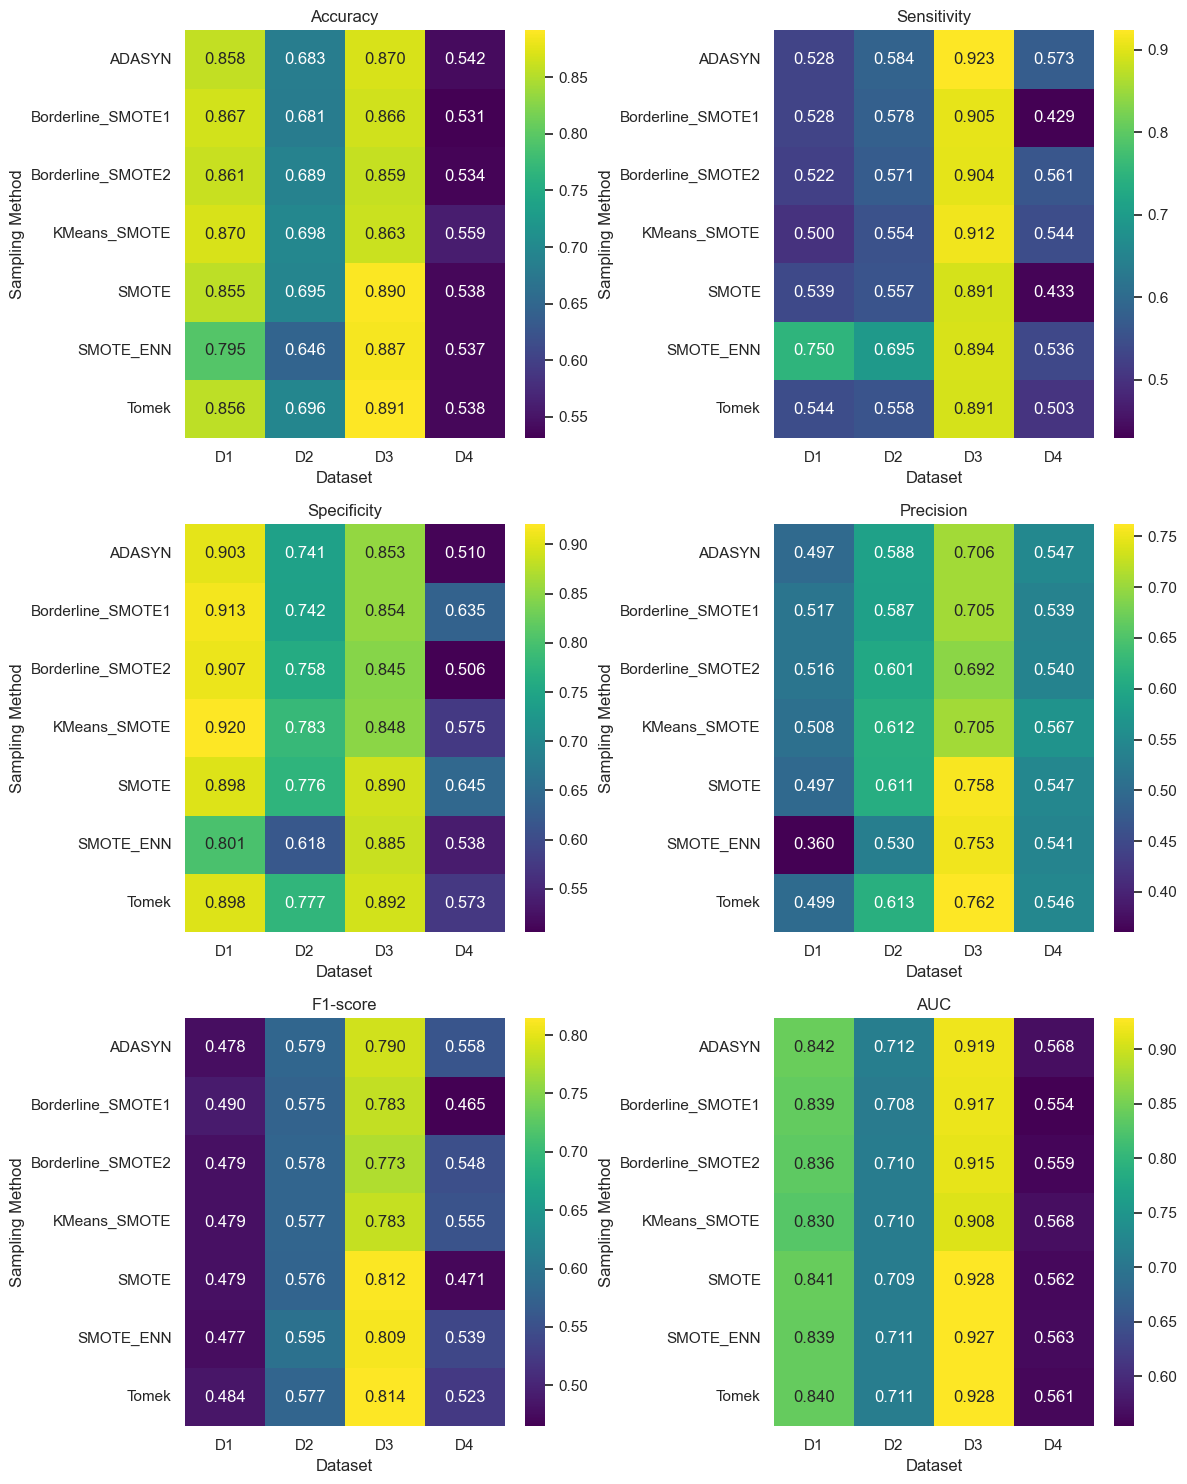

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metrics = [
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1-score",
    "AUC"
]

sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for i, metric in enumerate(metrics):

    row = i // 2
    col = i % 2

    pivot = all_data.pivot_table(
        values=metric,
        index="Sampling",
        columns="Dataset",
        aggfunc="mean"
    )

    sns.heatmap(
        pivot,
        annot=True,
        cmap="viridis",
        fmt=".3f",
        ax=axes[row, col]
    )

    axes[row, col].set_title(metric)
    axes[row, col].set_xlabel("Dataset")
    axes[row, col].set_ylabel("Sampling Method")

plt.tight_layout()
plt.show()